In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['text.usetex'] = True
from matplotlib.gridspec import GridSpec


In [2]:
def align(x, y):
    return np.sum(x*y)/( np.sqrt( np.sum(x**2)*np.sum(y**2) ) )  

In [23]:
d = 200
gamma_1 = 0.5
gamma_2 = 0.5
k1 = int(gamma_1*d)
k2 = int(gamma_2*d)
Delta = 0.2
v = np.mean(np.sort(np.random.randn(10000, k2), axis=1), axis=0)

alpha = 3.75
nsample = 100
m = 36
vmin, vmax = -2, 2

v1s = np.linspace(vmin, vmax, m+1)
v2s = np.linspace(vmin, vmax, m+1)
V1, V2 = np.meshgrid(v1s, v2s)

In [25]:
folder = f'alpha_{alpha}_v1/'

A_data = [[[] for _ in range(m)] for _ in range(m)] # W2 overlaps
B_data = [[] for _ in range(m)] # W2:1 overlaps
C_data = [[] for _ in range(m)] # W1 overlaps
G = np.linspace(vmin, vmax, m+1)

for k in range(nsample):
    W1a = np.loadtxt(folder + f'W1a_{k+1}.csv', delimiter=',')
    W10 = np.loadtxt(folder + f'W10_{k+1}.csv', delimiter=',')
    W2a = np.loadtxt(folder + f'W2a_{k+1}.csv', delimiter=',')
    W20 = np.loadtxt(folder + f'W20_{k+1}.csv', delimiter=',')
    # v = np.loadtxt(folder + f'v_{k+1}.csv', delimiter=',')
    v2 = v.T@W2a/np.sqrt(k2)

    W10 = W10[np.argsort(v2)]
    W1a = W1a[np.argsort(v2)]
    W2a = W2a[np.argsort(v)][:, np.argsort(v2)]
    W20 = W20[np.argsort(v)][:, np.argsort(v2)] ####
    W210 = W20@W10[np.argsort(v)]/np.sqrt(k1)
    W21a = W2a@W1a[np.argsort(v)]/np.sqrt(k1)

    v =np.sort(v)
    v2=np.sort(v2)

    # mapping readout values to bins
    v_map = np.digitize(v, G) - 1
    v2_map = np.digitize(v2, G) - 1

    # W2 overlaps
    for i2 in range(k2):
        for i1 in range(k1):
            j2, j1 = v_map[i2], v2_map[i1]
            if 0 <= j2 < m and 0 <= j1 < m:
                A_data[j2][j1].append( [W2a[i2, i1], W20[i2, i1]] )

    # overlaps of W2:1
    overlaps = [align(W210[i], W21a[i]) for i in range(k2)]
    for i in range(k2):
        j = v_map[i]
        if 0 <= j < m:
            B_data[j].append(overlaps[i])

    # overlaps of W1
    overlaps = [align(W10[i], W1a[i]) for i in range(k1)]
    for i in range(k1):
        j = v2_map[i]
        if 0 <= j < m:
            C_data[j].append(overlaps[i])
    

In [26]:
A = np.zeros((m,m))
for i in range(m):
    for j in range(m):
        if len(A_data[i][j])>0:
            w1, w2  = np.array(A_data[i][j]).T
            A[i,j] = align(w1, w2) 


B = np.array([np.mean(data) for data in B_data])
C = np.array([np.mean(data) for data in C_data])

B = B[:, np.newaxis]
C = C[np.newaxis, :]

A, B, C = np.abs(A), np.abs(B), np.abs(C)

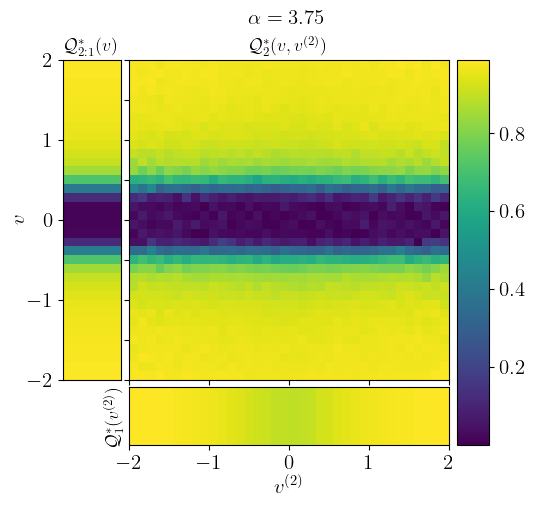

In [27]:
size=15
small=13
cmap = 'viridis'
fig = plt.figure(figsize=(5.5, 5))
gs = GridSpec(nrows=2, ncols=3, figure=fig, width_ratios=[0.18, 1, 0.1], height_ratios=[1, 0.18], hspace=0.04, wspace=0.06)

ax_main = fig.add_subplot(gs[0, 1])
im_main = ax_main.pcolormesh(V1, V2, np.abs(A), cmap=cmap, rasterized=True)
ax_main.set_xlim(vmin, vmax)
ax_main.set_ylim(vmin, vmax)
ax_main.set_xticklabels([])
ax_main.set_yticklabels([])
ax_main.set_title(r'$\mathcal Q_{2}^*(v, v^{(2)})$', fontsize=small, pad=6 )


ax_left = fig.add_subplot(gs[0, 0])
im_left = ax_left.pcolormesh([0, 1], v1s, np.abs(B), cmap=cmap, rasterized=True)
ax_left.set_ylabel(r'$v$', fontsize=size, labelpad=-1)
ax_left.set_xticks([])
ax_left.tick_params(axis='y', labelsize=size)
ax_left.set_ylim(vmin, vmax)
ax_left.set_title(r'$\mathcal Q^*_{2:1}(v)$', fontsize=small, pad=6)


ax_bottom = fig.add_subplot(gs[1, 1])
im_bottom = ax_bottom.pcolormesh(v2s, [0, 1], np.abs(C), cmap=cmap, rasterized=True)
ax_bottom.set_xlabel(r'$v^{(2)}$', fontsize=size)
ax_bottom.set_yticks([])
ax_bottom.tick_params(axis='x', labelsize=size)
ax_bottom.set_xlim(vmin, vmax)
ax_bottom.set_ylabel(r'$\mathcal Q^*_1(v^{(2)})$', fontsize=small)

# common colorbar
v_min = min(A.min(), B.min(), C.min())
v_max = max(A.max(), B.max(), C.max())

norm = matplotlib.colors.Normalize(vmin=v_min, vmax=v_max)

im_main.set_norm(norm)
im_left.set_norm(norm)
im_bottom.set_norm(norm)

mappable = matplotlib.cm.ScalarMappable(norm=norm, cmap=im_main.cmap)

ax_cbar = fig.add_subplot(gs[0:2, 2])
fig.colorbar(mappable, cax=ax_cbar, ticks=[0, 0.2, 0.4, 0.6, 0.8])
ax_cbar.tick_params(labelsize=size)

# plt.title(fr'$\alpha={alpha}$', loc='center')
fig.suptitle(fr'$\alpha={alpha}$', fontsize=size, x= 0.53, y=0.98)
plt.savefig(f'Q2heatmap_numerical_{alpha}.pdf', dpi=300)

# plt.show()